## 07 — Ideology-aware bias analysis (center vs non-center)

This notebook uses the ideology labels produced in **Notebook 06** to quantify **ideology skew** in recommendations and clicks.

**Key idea:** ideology labels are only defined for the *political* subset. We therefore report:
- how much politics appears in top-k (**politics share**), and
- within the political items shown, how many are **non-center** (**non-center share within politics**).

We keep the recommendation baselines consistent with the previous notebooks:
- **Popularity baseline**: rank candidates by global click count in TRAIN.
- **Category-preference baseline**: rank candidates by the user's preference for the candidate's news category, learned from TRAIN clicks.

### Imports and paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

PROJECT = Path().resolve().parent
PROCESSED = PROJECT / "data" / "processed"
print("PROJECT:", PROJECT)
print("PROCESSED:", PROCESSED)

PROJECT: C:\Users\jlsmp\Documents\universidade\M.IA\IAS\project
PROCESSED: C:\Users\jlsmp\Documents\universidade\M.IA\IAS\project\data\processed


### Loading

In [2]:
clicks_train = pd.read_pickle(PROCESSED / "clicks_train.pkl")
news_train   = pd.read_pickle(PROCESSED / "news_train.pkl")

clicks_dev = pd.read_pickle(PROCESSED / "clicks_dev.pkl")
news_dev   = pd.read_pickle(PROCESSED / "news_dev.pkl")

print("train clicks:", clicks_train.shape, "train news:", news_train.shape)
print("dev clicks:", clicks_dev.shape, "dev news:", news_dev.shape)


train clicks: (5843444, 9) train news: (51282, 8)
dev clicks: (2740998, 9) dev news: (42416, 8)


In [3]:
pol_train = pd.read_pickle(PROCESSED / "political_ideology_train.pkl")
pol_dev   = pd.read_pickle(PROCESSED / "political_ideology_dev.pkl")

print("political_ideology_train:", pol_train.shape)
print("political_ideology_dev  :", pol_dev.shape)

display(pol_train.head(3))


political_ideology_train: (2831, 15)
political_ideology_dev  : (2402, 15)


,news_id,title,abstract,category,subcategory,ideology_pred,ideology_conf,p_left,p_center,p_right,p_non_center,ideology_bin_pred,ideology_bin_conf,ideology_bin_margin,ideology_used
20,N9786,Elijah Cummings to lie in state at US Capitol ...,"Cummings, a Democrat whose district included s...",news,newspolitics,right,0.480308,0.340894,0.178798,0.480308,0.821202,non_center,0.821202,0.642404,non_center
127,N47214,Here are the lawmakers who are not seeking ree...,The battle for control of Congress is more tha...,news,newspolitics,left,0.565310,0.565310,0.183702,0.250988,0.816298,non_center,0.816298,0.632596,non_center
160,N24905,Grieder: Special election in House District 28...,The special election in Texas House District 2...,news,newspolitics,left,0.852884,0.852884,0.096972,0.050144,0.903028,non_center,0.903028,0.806056,non_center


###  Build a fast lookup from `news_id` → ideology label

I use a dictionary to quickly map ideology onto candidates in each impression.

In [4]:
ideology_used_map = dict(zip(pol_train["news_id"], pol_train["ideology_used"]))
ideology_used_map.update(dict(zip(pol_dev["news_id"], pol_dev["ideology_used"])))

ideology_3class_map = dict(zip(pol_train["news_id"], pol_train.get("ideology_pred", pd.Series(index=pol_train.index, dtype=object))))
ideology_3class_map.update(dict(zip(pol_dev["news_id"], pol_dev.get("ideology_pred", pd.Series(index=pol_dev.index, dtype=object)))))

print("Ideology labels in map:", len(ideology_used_map))


Ideology labels in map: 3483


### Define "politically engaged" users (same rule as Notebook 04)

We keep the previous definition to stay consistent:
- A user is *politically engaged* if they have **≥ 3 clicked political items in TRAIN**.

To detect political items, we reuse the same heuristic: subcategory contains `"polit"`.

In [5]:
news_train["is_politics"] = news_train["subcategory"].str.contains("polit", case=False, na=False)
polit_ids_train = set(news_train.loc[news_train["is_politics"], "news_id"])

clicks_train["is_politics"] = clicks_train["news_id"].isin(polit_ids_train)

pol_clicks_per_user = (
    clicks_train.loc[(clicks_train["clicked"]==1) & (clicks_train["is_politics"])]
    .groupby("user_id").size()
)

engaged_users = set(pol_clicks_per_user[pol_clicks_per_user >= 3].index)

print("Politically engaged users (>=3 political clicks in TRAIN):", len(engaged_users))


Politically engaged users (>=3 political clicks in TRAIN): 627


### Build DEV impression structures (same as Notebook 04)

`clicks_dev` contains an `impression_id`, a `user_id`, a candidate `news_id`, and a `clicked` label (0/1).

Group by impression:
- `impression_candidates[imp_id]` → list of candidate news_id
- `impression_labels[imp_id]` → list of 0/1 labels in the same order

In [6]:
dev_groups = clicks_dev.groupby("impression_id")
impression_candidates = dev_groups["news_id"].apply(list)
impression_labels     = dev_groups["clicked"].apply(list)
imp_user              = dev_groups["user_id"].first()

print("DEV impressions:", len(impression_candidates))
print("Example impression_id:", impression_candidates.index[0])
print("Candidates:", impression_candidates.iloc[0][:5])
print("Labels    :", impression_labels.iloc[0][:5])


DEV impressions: 73152
Example impression_id: 1
Candidates: ['N28682', 'N48740', 'N31958', 'N34130', 'N6916']
Labels    : [0, 0, 1, 0, 0]


### Define recommendation baselines (same as Notebook 04)

**Popularity baseline**

Score of a news item = total number of clicks it received in TRAIN.

In [7]:
pop_clicks = clicks_train.groupby("news_id")["clicked"].sum()
pop_score  = pop_clicks.to_dict()

def pop_score_fn(imp_id, news_id):
    return float(pop_score.get(news_id, 0.0))

print("Popularity dict size:", len(pop_score))


Popularity dict size: 20288


### Category-preference baseline (user preference)

From TRAIN clicks only, a per-user distribution over **news categories** was learned (as in Notebook 04).

Additionally, for users who clicked political news in TRAIN, we also learn a **binary ideology preference** within politics (`center` vs `non_center`) using the ideology labels produced in Notebook 06.

Scoring in DEV:
- For **non-political** candidates: score = user's category preference for that category.
- For **political** candidates (ideology label available): score = category preference × user's ideology preference
  for that ideology label (defaulting to 0.5 if the user has no political click history).

This keeps the baseline consistent with the idea of *preference matching* while making ideology explicit.


In [ ]:
train_meta = news_train.set_index("news_id")[["category","subcategory"]]

train_clicks_only = clicks_train.loc[clicks_train["clicked"] == 1, ["user_id","news_id"]].copy()
train_clicks_only = train_clicks_only.join(train_meta, on="news_id", how="left")

user_cat_counts = (
    train_clicks_only.groupby(["user_id","category"])
    .size()
    .rename("cnt")
    .reset_index()
)

user_total = user_cat_counts.groupby("user_id")["cnt"].transform("sum")
user_cat_counts["pref"] = user_cat_counts["cnt"] / user_total

user_pref_cat = {
    uid: dict(zip(chunk["category"], chunk["pref"]))
    for uid, chunk in user_cat_counts.groupby("user_id")
}

print("Users with learned category preferences:", len(user_pref_cat))



#  Ideology preferences from TRAIN clicks (politics only)
pol_train = pd.read_pickle(PROCESSED / "political_ideology_train.pkl")

train_pol_clicks = (
    clicks_train.loc[clicks_train["clicked"] == 1, ["user_id","news_id"]]
    .merge(pol_train[["news_id","ideology_used"]], on="news_id", how="inner")
)

user_ideo = train_pol_clicks.groupby("user_id").agg(
    pol_clicks=("news_id","count"),
    non_center_clicks=("ideology_used", lambda s: (s == "non_center").sum())
).reset_index()

user_ideo["pref_non_center"] = user_ideo["non_center_clicks"] / user_ideo["pol_clicks"]
user_ideo["pref_center"] = 1.0 - user_ideo["pref_non_center"]

user_pref_ideo = user_ideo.set_index("user_id")[["pref_center","pref_non_center"]].to_dict("index")

print("Users with learned ideology preferences (politics clicks):", len(user_pref_ideo))



#  DEV metadata + DEV ideology lookup (only for politics)

dev_meta = news_dev.set_index("news_id")[["category","subcategory"]]

pol_dev = pd.read_pickle(PROCESSED / "political_ideology_dev.pkl")
dev_pol_ideo = pol_dev.set_index("news_id")["ideology_used"].to_dict()  # news_id -> center/non_center


# Scoring function: category preference + ideology preference (politics only)

SMOOTH = 0.50 

def cat_ideology_personal_score_fn(imp_id, news_id):
    uid = imp_user[imp_id]

    if news_id not in dev_meta.index:
        return 0.0

    cat = dev_meta.loc[news_id, "category"]
    base = float(user_pref_cat.get(uid, {}).get(cat, 0.0))

    ideo = dev_pol_ideo.get(news_id, None)
    if ideo is None:
        return base

    prefs = user_pref_ideo.get(uid, None)
    if prefs is None:
        pref_center = SMOOTH
        pref_non_center = 1.0 - SMOOTH
    else:
        pref_center = float(prefs["pref_center"])
        pref_non_center = float(prefs["pref_non_center"])

    if ideo == "non_center":
        return base * pref_non_center
    elif ideo == "center":
        return base * pref_center
    else:
        return base


Users with learned category preferences: 50000
Users with learned ideology preferences (politics clicks): 6067


### Metrics: ideology & politics shares in top-k recommendations

Because ideology is only defined for political items, I report **two** related metrics:

1) **Politics share in top-k**  

- fraction of the top-k items that are political (i.e., have an ideology label available)

2) **Non-center share within politics (top-k)**  

- among the political items in the top-k, what fraction are labeled `non_center`?

We compute these metrics per impression, and then aggregate separately for:
- politically engaged users
- other users


In [15]:
def _engaged_ideology_group(uid, engaged_users, user_pref_ideo, mode="3way"):
    """
    mode:
      - "2way": engaged_center if pref_non_center < 0.5 else engaged_noncenter
      - "3way": engaged_center if <=0.40, engaged_noncenter if >=0.60, else engaged_mixed
    """
    if uid not in engaged_users:
        return "other"

    pref = user_pref_ideo.get(uid, None)
    if pref is None:
        return "engaged_mixed" if mode == "3way" else "engaged_noncenter" 

    p_non = float(pref.get("pref_non_center", 0.5))

    if mode == "2way":
        return "engaged_noncenter" if p_non >= 0.5 else "engaged_center"

    if p_non <= 0.40:
        return "engaged_center"
    if p_non >= 0.60:
        return "engaged_noncenter"
    return "engaged_mixed"


def topk_ideology_metrics(score_fn, k=10, max_impressions=20000, group_mode="3way"):
    ids = impression_candidates.index[:max_impressions]
    rows = []

    for imp_id in ids:
        uid = imp_user[imp_id]
        cands = impression_candidates[imp_id]

        scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
        order = np.argsort(-scores)
        top = [cands[i] for i in order[:k]]

        # Ideology only defined for items in ideology_used_map (political items)
        ideos = [ideology_used_map.get(nid, None) for nid in top]
        pol_mask = [v is not None for v in ideos]
        pol_in_top = int(np.sum(pol_mask))

        noncenter_in_top = int(np.sum([v == "non_center" for v in ideos if v is not None]))
        center_in_top    = int(np.sum([v == "center" for v in ideos if v is not None]))

        politics_share = pol_in_top / k
        noncenter_share_total = noncenter_in_top / k  # treats non-politics as 0 contribution

        # within-politics rate (undefined if no politics appears in top-k)
        noncenter_within_politics = (noncenter_in_top / pol_in_top) if pol_in_top > 0 else np.nan

        rows.append({
            "impression_id": imp_id,
            "user_id": uid,
            "group": _engaged_ideology_group(uid, engaged_users, user_pref_ideo, mode=group_mode),
            "politics_share_topk": politics_share,
            "noncenter_share_total_topk": noncenter_share_total,
            "noncenter_share_within_politics_topk": noncenter_within_politics,
            "politics_in_topk": pol_in_top,
            "noncenter_in_topk": noncenter_in_top,
            "center_in_topk": center_in_top
        })

    return pd.DataFrame(rows)


def summarize_topk(df, k=10):
    out = df.groupby("group").agg(
        n_impressions=("impression_id", "count"),
        politics_share=("politics_share_topk", "mean"),
        noncenter_share_total=("noncenter_share_total_topk", "mean"),
        noncenter_share_within_politics=("noncenter_share_within_politics_topk", "mean"),
    ).sort_index()
    return out


### Compute top-k ideology metrics for each baseline

In [17]:
K = 10
MAX_IMP = 20000  

topk_pop = topk_ideology_metrics(pop_score_fn, k=K, max_impressions=MAX_IMP, group_mode="3way")
topk_cat = topk_ideology_metrics(cat_ideology_personal_score_fn, k=K, max_impressions=MAX_IMP, group_mode="3way")

print("Popularity baseline (top-k ideology metrics):")
display(summarize_topk(topk_pop, k=K))

print("Category-preference baseline (top-k ideology metrics):")
display(summarize_topk(topk_cat, k=K))


Popularity baseline (top-k ideology metrics):


,n_impressions,politics_share,noncenter_share_total,noncenter_share_within_politics
group,,,,
engaged_noncenter,88,0.039773,0.039773,1.000000
other,19912,0.021706,0.021424,0.986107


Category-preference baseline (top-k ideology metrics):


,n_impressions,politics_share,noncenter_share_total,noncenter_share_within_politics
group,,,,
engaged_noncenter,88,0.136364,0.136364,1.000000
other,19912,0.041864,0.040388,0.963359


### Interpretation (top-k ideology metrics)

Across both baselines, the share of political content in the top-10 is relatively small, but increases
substantially under the category-preference baseline (as expected from personalization).

However, when political items appear, they are overwhelmingly labeled as `non_center`.
This results in `noncenter_share_within_politics` close to 1.0, meaning the ideology composition of
recommended political content is almost entirely non-center.

I will analyse better to get results, since I think this huge difference between non_center and center is do to the fact that there is less center data causing the value of center engaged users to be 0 probably (no user in train interacted with 3 center articles or more).


In [18]:
topk_pop.groupby("group")["politics_in_topk"].describe()
topk_cat.groupby("group")["politics_in_topk"].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
engaged_noncenter,88.0,1.363636,1.305883,0.0,0.0,1.0,2.0,5.0
other,19912.0,0.418642,0.710038,0.0,0.0,0.0,1.0,10.0


In [19]:
pol_catalog_share = pd.Series(ideology_used_map).value_counts(normalize=True)
pol_catalog_share

non_center    0.923342
center        0.076658
Name: proportion, dtype: float64

### Why `engaged_center` is missing

Although `center` exists as a class, it represents a small fraction of the political catalog
(≈7.7% vs 92.3% non_center). With an engagement threshold based on political clicks (≥3),
most engaged users still accumulate predominantly non_center clicks simply due to availability.
As a result, splitting engaged users into “center-leaning vs non-center-leaning” yields almost no
`engaged_center` group in practice.

This does not imply that users never click center articles; rather, it indicates that center content
is too rare for many users to become “center-majority” in their click history. To study the role of
center content, we therefore analyze users with **any center click(s)** separately and/or perform a
temporal event-style analysis around center-click events.


## Update: Center is rare — redefine user groups for interpretable analysis

The political catalog is highly imbalanced (≈92% `non_center`, ≈8% `center`).  
Because of this, splitting engaged users into “center-leaning vs non-center-leaning” using majority thresholds is not reliable: most engaged users will still appear non_center-leaning simply due to the availability of content.

To preserve interpretability, I instead distinguish engaged users by whether they ever clicked a `center` political article in TRAIN:

- **engaged_with_center_clicks**: engaged users with ≥1 center political click (TRAIN)
- **engaged_no_center_clicks**: engaged users with 0 center political clicks (TRAIN)
- **other**: non-engaged users

This grouping lets us study whether any exposure/click patterns differ for users who interacted with
center content, even if center is rare overall.


In [21]:
center_clicks_per_user = (
    train_pol_clicks.assign(is_center=train_pol_clicks["ideology_used"].eq("center"))
    .groupby("user_id")["is_center"].sum()
)

engaged_with_center_clicks = set(center_clicks_per_user[center_clicks_per_user >= 1].index) & set(engaged_users)
engaged_no_center_clicks   = (set(engaged_users) - engaged_with_center_clicks)

print("Users engaged total:", len(engaged_users))
print("Engaged with ≥1 center click:", len(engaged_with_center_clicks))
print("Engaged with 0 center clicks:", len(engaged_no_center_clicks))

def user_group(uid):
    if uid in engaged_users:
        return "engaged_with_center_clicks" if uid in engaged_with_center_clicks else "engaged_no_center_clicks"
    return "other"


Users engaged total: 627
Engaged with ≥1 center click: 129
Engaged with 0 center clicks: 498


### Recompute top-k ideology metrics using the new grouping

I re-run the same top-k evaluation as before, but with the refined user groups.  
This preserves the same baselines:

- **Popularity baseline**: ranks candidates by global popularity.
- **Preference baseline (category + ideology)**: ranks by user category preference, and for political items also matches the user's center vs non_center preference learned from TRAIN.

- `politics_share`: fraction of top-k that is political
- `noncenter_share_within_politics`: fraction of political items in top-k that are non_center


In [27]:
def topk_ideology_metrics_grouped(score_fn, k=10, max_impressions=20000):
    ids = impression_candidates.index[:max_impressions]
    rows = []

    for imp_id in ids:
        uid = imp_user[imp_id]
        cands = impression_candidates[imp_id]

        scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
        order = np.argsort(-scores)
        top = [cands[i] for i in order[:k]]

        ideos = [ideology_used_map.get(nid, None) for nid in top]
        pol_in_top = int(np.sum([v is not None for v in ideos]))

        noncenter_in_top = int(np.sum([v == "non_center" for v in ideos if v is not None]))
        politics_share = pol_in_top / k
        noncenter_share_total = noncenter_in_top / k
        noncenter_within_politics = (noncenter_in_top / pol_in_top) if pol_in_top > 0 else np.nan

        rows.append({
            "impression_id": imp_id,
            "user_id": uid,
            "group": user_group(uid),
            "politics_share_topk": politics_share,
            "noncenter_share_total_topk": noncenter_share_total,
            "noncenter_share_within_politics_topk": noncenter_within_politics,
            "politics_in_topk": pol_in_top,
            "noncenter_in_topk": noncenter_in_top,
        })

    return pd.DataFrame(rows)

def summarize_topk(df):
    return (
        df.groupby("group")
          .agg(
              n_impressions=("impression_id", "count"),
              politics_share=("politics_share_topk", "mean"),
              noncenter_share_total=("noncenter_share_total_topk", "mean"),
              noncenter_share_within_politics=("noncenter_share_within_politics_topk", "mean"),
          )
          .sort_index()
    )

K = 10
MAX_IMP = 20000

topk_pop = topk_ideology_metrics_grouped(pop_score_fn, k=K, max_impressions=MAX_IMP)
topk_cat = topk_ideology_metrics_grouped(cat_ideology_personal_score_fn, k=K, max_impressions=MAX_IMP)

print("Popularity baseline (grouped):")
display(summarize_topk(topk_pop))

print("Preference baseline: category + ideology (grouped):")
display(summarize_topk(topk_cat))


Popularity baseline (grouped):


,n_impressions,politics_share,noncenter_share_total,noncenter_share_within_politics
group,,,,
engaged_no_center_clicks,63,0.036508,0.036508,1.000000
engaged_with_center_clicks,25,0.048000,0.048000,1.000000
other,19912,0.021706,0.021424,0.986107


Preference baseline: category + ideology (grouped):


,n_impressions,politics_share,noncenter_share_total,noncenter_share_within_politics
group,,,,
engaged_no_center_clicks,63,0.152381,0.152381,1.000000
engaged_with_center_clicks,25,0.096000,0.096000,1.000000
other,19912,0.041864,0.040388,0.963359


In [28]:
for df in [topk_pop, topk_cat]:
    df["center_in_topk"] = df["politics_in_topk"] - df["noncenter_in_topk"]

topk_pop.groupby("group")["center_in_topk"].sum()
topk_cat.groupby("group")["center_in_topk"].sum()


group
engaged_no_center_clicks        0
engaged_with_center_clicks      0
other                         294
Name: center_in_topk, dtype: int64

In [30]:
topk_pop.groupby("group")["politics_in_topk"].value_counts().sort_index()
topk_cat.groupby("group")["politics_in_topk"].value_counts().sort_index()


group                       politics_in_topk
engaged_no_center_clicks    0                      17
                            1                      16
                            2                      18
                            3                       5
                            4                       6
                            5                       1
engaged_with_center_clicks  0                      10
                            1                      11
                            2                       1
                            3                       2
                            5                       1
other                       0                   13593
                            1                    4708
                            2                    1311
                            3                     231
                            4                      46
                            5                      16
                            6        

### What is being reported
For each impression, we rank the candidate articles with two baselines and look at the **top-10**:

- **Popularity baseline**: ranks by global popularity.
- **Preference baseline (category + ideology)**: ranks by user category preference; for political items, it also
  boosts items whose ideology (`center` vs `non_center`) matches the user’s observed ideology preference from TRAIN clicks.

Users are grouped as:
- **engaged_with_center_clicks**: politically engaged users who clicked ≥1 `center` political item in TRAIN
- **engaged_no_center_clicks**: politically engaged users with 0 `center` clicks in TRAIN
- **other**: users not classified as politically engaged

Metrics:
- `politics_share`: average fraction of top-10 that is political (0.05 means ~0.5 political items per top-10)
- `noncenter_share_total`: average fraction of top-10 that is `non_center` political (non-politics count as 0)
- `noncenter_share_within_politics`: among political items that appear in top-10, the fraction that is `non_center`

---

### Why `politics_share == noncenter_share_total` and `noncenter_share_within_politics = 1.0`
For the two engaged groups, **`center_in_topk = 0`**, i.e., across all evaluated impressions:

- **engaged_no_center_clicks**: 0 center items in top-10
- **engaged_with_center_clicks**: 0 center items in top-10

This implies that **every political item that appears in top-10 is labeled `non_center`**.  
Therefore:

- `politics_share` equals `noncenter_share_total` because *all* political items are non_center.
- `noncenter_share_within_politics = 1.0` because *(# non_center political items) / (# political items) = 1*.

For the **other** group, some center items do appear (`center_in_topk = 294`), but the within-politics
non_center share is still very high (≈0.96–0.99), consistent with the strong catalog imbalance.

---

### How often does politics appear in top-10?
The `politics_in_topk` distribution shows how many political items appear in each top-10 list.

- **engaged_no_center_clicks (63 impressions)**:
  - 17 impressions have 0 political items in top-10 → politics appears in **46/63 ≈ 73%** of impressions.
- **engaged_with_center_clicks (25 impressions)**:
  - 10 impressions have 0 political items → politics appears in **15/25 = 60%** of impressions.
- **other (19912 impressions)**:
  - most impressions have 0 political items (13593) → politics appears in **6319/19912 ≈ 32%** of impressions.

So political exposure is higher for engaged users (expected), especially under the preference baseline.

---

### Main takeaways from these results
1) **Personalization increases political exposure**  
   The preference baseline increases `politics_share` substantially relative to popularity, especially for engaged users
   (e.g., ~0.15 for engaged_no_center_clicks vs ~0.04 under popularity).

2) **Ideology exposure is dominated by `non_center`**  
   For engaged users, political recommendations in top-10 are exclusively `non_center` in this evaluation window
   (0 center items observed). Even for “other” users, center appears but remains a small minority.

3) **This does not prove reinforcement by itself**  
   Because `center` is rare in the catalog, a lack of center in top-10 could happen due to:
   - availability imbalance (few center items exist),
   - scoring that selects higher-scoring non_center items,
   - small sample sizes for engaged groups (63 and 25 impressions).

---

## Next steps
To understand whether this is **just availability** or **amplification**, we will:

1) **Compare recommendations to the catalog baseline**  
   Compute the expected number of center items in top-10 given the catalog center share,
   and compare it to the observed center exposure (0 for engaged groups).

2) **Compare exposure vs consumption (clicks in DEV)**  
   Measure `P(non_center | clicked politics)` by group and compare it to
   `P(non_center | recommended politics)` to separate user selection effects from system exposure.

These steps allow us to discuss bias and potential reinforcement in a way that is fair even under severe class imbalance.


In [32]:
catalog_dist = pd.Series(ideology_used_map).value_counts(normalize=True)
catalog_noncenter = float(catalog_dist.get("non_center", np.nan))
catalog_center = float(catalog_dist.get("center", np.nan))

print("Catalog within-politics distribution (from ideology_used_map):")
print("  non_center:", catalog_noncenter)
print("  center    :", catalog_center)

pol_expo_pop = topk_pop.groupby("group")["politics_in_topk"].sum()
pol_expo_cat = topk_cat.groupby("group")["politics_in_topk"].sum()

print("\nTotal political exposures in top-k (popularity):")
display(pol_expo_pop)

print("Total political exposures in top-k (preference):")
display(pol_expo_cat)

exp_center_pop = (pol_expo_pop * catalog_center).round(2)
exp_center_cat = (pol_expo_cat * catalog_center).round(2)

print("\nExpected center exposures if matching catalog (popularity):")
display(exp_center_pop)

print("Expected center exposures if matching catalog (preference):")
display(exp_center_cat)

for df in [topk_pop, topk_cat]:
    if "center_in_topk" not in df.columns:
        df["center_in_topk"] = df["politics_in_topk"] - df["noncenter_in_topk"]

obs_center_pop = topk_pop.groupby("group")["center_in_topk"].sum()
obs_center_cat = topk_cat.groupby("group")["center_in_topk"].sum()

print("\nObserved center exposures (popularity):")
display(obs_center_pop)

print("Observed center exposures (preference):")
display(obs_center_cat)


Catalog within-politics distribution (from ideology_used_map):
  non_center: 0.9233419465977606
  center    : 0.07665805340223945

Total political exposures in top-k (popularity):


group
engaged_no_center_clicks        23
engaged_with_center_clicks      12
other                         4322
Name: politics_in_topk, dtype: int64

Total political exposures in top-k (preference):


group
engaged_no_center_clicks        96
engaged_with_center_clicks      24
other                         8336
Name: politics_in_topk, dtype: int64


Expected center exposures if matching catalog (popularity):


...

group
engaged_no_center_clicks        7.36
engaged_with_center_clicks      1.84
other                         639.02
Name: politics_in_topk, dtype: float64


Observed center exposures (popularity):


group
engaged_no_center_clicks       0
engaged_with_center_clicks     0
other                         56
Name: center_in_topk, dtype: int64

Observed center exposures (preference):


group
engaged_no_center_clicks        0
engaged_with_center_clicks      0
other                         294
Name: center_in_topk, dtype: int64

### Sanity check: expected vs observed center exposure (interpretation)

### 1) Catalog baseline
Within the political subset, the ideology labels are highly imbalanced:

- `non_center` ≈ 92.3%
- `center` ≈ 7.7%

This means that even an *unbiased* selection of political items would include relatively few center articles.

---

### 2) Total political exposure in top-k
We count how many political items appear across all evaluated top-10 lists (sum of `politics_in_topk`):

**Popularity baseline**
- engaged_no_center_clicks: 23 political exposures
- engaged_with_center_clicks: 12 political exposures
- other: 4322 political exposures

**Preference baseline**
- engaged_no_center_clicks: 96 political exposures
- engaged_with_center_clicks: 24 political exposures
- other: 8336 political exposures

As expected, the preference baseline increases political exposure, especially for engaged users.

---

### 3) Expected center exposure if recommendations matched the catalog
If the recommended political items reflected the catalog distribution (7.7% center), we would expect:

**Popularity baseline (expected center)**
- engaged_no_center_clicks: ~1.76 center items
- engaged_with_center_clicks: ~0.92 center items
- other: ~331 center items

**Preference baseline (expected center)**
- engaged_no_center_clicks: ~7.36 center items
- engaged_with_center_clicks: ~1.84 center items
- other: ~639 center items

So, even under the catalog imbalance, we would still expect *some* center items to appear in top-k,
especially in the large "other" group and in the preference baseline (which surfaces more political items overall).

---

### 4) Observed center exposure is much lower than expected
Observed center items in top-k:

**Popularity baseline (observed center)**
- engaged_no_center_clicks: 0
- engaged_with_center_clicks: 0
- other: 56

**Preference baseline (observed center)**
- engaged_no_center_clicks: 0
- engaged_with_center_clicks: 0
- other: 294

This shows a clear gap between expected and observed center exposure:

- For engaged users, **center never appears in top-k**, even though (under catalog proportions) we would expect
  around 1–2 center items for popularity and around 2–7 for preference.
- For "other" users, center appears but is still far below expectation:
  - popularity: 56 observed vs ~331 expected
  - preference: 294 observed vs ~639 expected

---

### 5) What this suggests (careful conclusion)
These results indicate that the recommendation outputs are **more skewed toward `non_center` than the catalog baseline alone would predict**.
In other words, the lack of center exposure is not only due to the fact that center is rare in the catalog;
it is also consistent with the ranking/scoring function selecting non_center political items disproportionately.

However, we still need to separate two possibilities:
1) **Selection effect in the candidate pool**: the set of candidates shown for each impression may already contain
   very few center political items.
2) **Ranking effect**: center items may exist in the candidates but are being systematically ranked lower.

To distinguish these, we next measure center presence in the candidate sets (before ranking) and compare it to
center presence in the selected top-k (after ranking). We also compare exposure to users' clicks to assess
whether users amplify the skew further through their consumption choices.


In [33]:
def candidate_pool_center_rate(max_impressions=20000):
    ids = impression_candidates.index[:max_impressions]
    rows = []
    for imp_id in ids:
        uid = imp_user[imp_id]
        cands = impression_candidates[imp_id]
        ideos = [ideology_used_map.get(nid, None) for nid in cands]
        pol = [v for v in ideos if v is not None]
        if len(pol) == 0:
            continue
        center = sum(v=="center" for v in pol)
        rows.append({
            "group": user_group(uid),
            "pol_candidates": len(pol),
            "center_candidates": center,
            "center_rate_candidates": center / len(pol)
        })
    return pd.DataFrame(rows)

cand_stats = candidate_pool_center_rate(MAX_IMP)
display(cand_stats.groupby("group")[["pol_candidates","center_candidates","center_rate_candidates"]].mean())


,pol_candidates,center_candidates,center_rate_candidates
group,,,
engaged_no_center_clicks,3.460000,0.180000,0.052190
engaged_with_center_clicks,2.782609,0.130435,0.030193
other,3.144071,0.166566,0.046541


### Candidate pool vs top-k: why does center disappear?

To understand whether the lack of `center` in the top-10 is caused by the **ranking** itself or by the **candidate pool** (what the system is allowed to choose from), I measured the ideology composition of the *political candidates* available in each impression **before** ranking.

The table reports (averaged per impression, grouped by user type):
- `pol_candidates`: average number of political items in the candidate set for an impression
- `center_candidates`: average number of center-labeled political items in the candidate set
- `center_rate_candidates`: average share of center items among political candidates

### What the numbers say
Across all groups, the candidate sets contain only **~3 political candidates per impression** on average:
- engaged_no_center_clicks: ~3.46 political candidates
- engaged_with_center_clicks: ~2.78 political candidates
- other: ~3.14 political candidates

Among those political candidates, center appears **very rarely**:
- engaged_no_center_clicks: ~0.18 center candidates per impression (≈5.2% of political candidates)
- engaged_with_center_clicks: ~0.13 center candidates per impression (≈3.0% of political candidates)
- other: ~0.17 center candidates per impression (≈4.7% of political candidates)

### Interpretation
These results show that **center is already under-represented in the candidate pool itself** (only ~3–5% of political candidates are center), which is even lower than the overall catalog baseline (~7.7% center).

This strongly suggests a **selection / availability bottleneck**:
- even before ranking, the system has very few center political items to choose from in each impression;
- with only ~3 political candidates available, the expected number of center candidates per impression is far below 1, so it is plausible that many impressions contain **zero** center candidates.

This helps explain why our top-k exposure analysis found **0 observed center items** for engaged users:
- center items are often not present in the candidate pool, so they cannot appear in the recommended top-k regardless of the ranking method.

### What this means for the bias/reinforcement discussion
The observed non_center dominance in top-k recommendations is driven not only by ranking, but also by the upstream candidate generation process (what enters the pool). This is important because mitigation strategies differ:

- If the issue were mostly ranking, we could address it with re-ranking / calibration.
- Since the issue also exists at the candidate stage, effective mitigation may require ensuring that candidate pools contain at least some ideological diversity (e.g., quotas, diversification constraints, or sampling adjustments for political items).




### Event study setup: does a center click at time *t* change exposure at *t+1*?

Because `center` items are rare, aggregate preference-based comparisons can hide center effects.
Instead, we perform an *event study* similar to the temporal analysis in Notebook 05:

**Event definition (time t):** an impression where the user clicked at least one political item labeled `center`.  
**Outcome (time t+1):** ideology composition of the candidate pool and recommended top-k in the next impression for the same user.

This isolates the short-term response of the recommender after a center interaction.


In [34]:
cols = clicks_dev.columns
imp_col = "impression_id" if "impression_id" in cols else ("imp_id" if "imp_id" in cols else None)
uid_col = "user_id" if "user_id" in cols else ("uid" if "uid" in cols else None)
nid_col = "news_id" if "news_id" in cols else ("nid" if "nid" in cols else None)
clk_col = "clicked" if "clicked" in cols else ("click" if "click" in cols else None)

assert imp_col and uid_col and nid_col and clk_col, f"Missing expected columns in clicks_dev: {clicks_dev.columns}"

dev_clicks_only = clicks_dev.loc[clicks_dev[clk_col] == 1, [imp_col, uid_col, nid_col]].copy()
dev_clicks_only["ideo"] = dev_clicks_only[nid_col].map(ideology_used_map)  # None if non-political / unknown

imp_clicked = (
    dev_clicks_only.groupby(imp_col)
    .agg(
        user_id=(uid_col, "first"),
        clicked_news=(nid_col, lambda s: list(s)),
        clicked_ideos=("ideo", lambda s: list(s))
    )
    .reset_index()
)

imp_df = pd.DataFrame({imp_col: impression_candidates.index})
imp_df["user_id"] = imp_df[imp_col].map(imp_user)
imp_df = imp_df.merge(imp_clicked, on=[imp_col, "user_id"], how="left")
imp_df["clicked_news"] = imp_df["clicked_news"].apply(lambda x: x if isinstance(x, list) else [])
imp_df["clicked_ideos"] = imp_df["clicked_ideos"].apply(lambda x: x if isinstance(x, list) else [])

def has_center(ideos): 
    return any(v == "center" for v in ideos if v is not None)
def has_noncenter(ideos): 
    return any(v == "non_center" for v in ideos if v is not None)
def has_politics(ideos):
    return any(v is not None for v in ideos)

imp_df["event_center_click_t"] = imp_df["clicked_ideos"].apply(has_center)
imp_df["event_noncenter_click_t"] = imp_df["clicked_ideos"].apply(has_noncenter)
imp_df["event_any_politics_click_t"] = imp_df["clicked_ideos"].apply(has_politics)

imp_df["_order"] = np.arange(len(imp_df), dtype=int)  # stable chronological proxy used in prior notebooks
imp_df = imp_df.sort_values(["user_id", "_order"]).reset_index(drop=True)

imp_df["imp_t1"] = imp_df.groupby("user_id")[imp_col].shift(-1)

print("Total impressions:", len(imp_df))
print("Center-click events (t):", int(imp_df["event_center_click_t"].sum()))
print("Non-center-click events (t):", int(imp_df["event_noncenter_click_t"].sum()))
print("Any-politics-click events (t):", int(imp_df["event_any_politics_click_t"].sum()))


Total impressions: 73152
Center-click events (t): 117
Non-center-click events (t): 4261
Any-politics-click events (t): 73152


### Metrics at *t+1*: availability vs ranking

At the next impression (t+1), we measure two things:

1) **Candidate availability**: how many political items are in the candidate pool, and how many are `center`.
   This tells us whether center is even available to be recommended.

2) **Recommended exposure (top-k)**: for each baseline (popularity and preference), how many political items
   and how many `center` items appear in the top-k list.

This separates *candidate bottleneck* from *ranking behavior*.


In [35]:
K = 10

def candidate_metrics(imp_id):
    cands = impression_candidates.get(imp_id, [])
    ideos = [ideology_used_map.get(nid, None) for nid in cands]
    pol = [v for v in ideos if v is not None]
    pol_n = len(pol)
    center_n = sum(v == "center" for v in pol)
    noncenter_n = sum(v == "non_center" for v in pol)
    return {
        "pol_candidates": pol_n,
        "center_candidates": center_n,
        "noncenter_candidates": noncenter_n,
        "center_rate_candidates": (center_n / pol_n) if pol_n > 0 else np.nan,
    }

def topk_metrics(imp_id, score_fn, k=10):
    cands = impression_candidates.get(imp_id, [])
    if len(cands) == 0:
        return {
            "politics_in_topk": 0,
            "center_in_topk": 0,
            "noncenter_in_topk": 0,
            "center_within_politics_topk": np.nan
        }
    scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
    order = np.argsort(-scores)
    top = [cands[i] for i in order[:k]]

    ideos = [ideology_used_map.get(nid, None) for nid in top]
    pol = [v for v in ideos if v is not None]
    pol_n = len(pol)
    center_n = sum(v == "center" for v in pol)
    noncenter_n = sum(v == "non_center" for v in pol)

    return {
        "politics_in_topk": pol_n,
        "center_in_topk": center_n,
        "noncenter_in_topk": noncenter_n,
        "center_within_politics_topk": (center_n / pol_n) if pol_n > 0 else np.nan
    }

def eval_t1_rows(t1_ids, score_fn, prefix):
    rows = []
    for imp_id in t1_ids:
        if pd.isna(imp_id):
            continue
        imp_id = int(imp_id) if isinstance(imp_id, (np.integer, int)) or str(imp_id).isdigit() else imp_id
        r = {"imp_t1": imp_id}
        r.update({f"{prefix}_{k}": v for k, v in candidate_metrics(imp_id).items()})
        r.update({f"{prefix}_{k}": v for k, v in topk_metrics(imp_id, score_fn, k=K).items()})
        rows.append(r)
    return pd.DataFrame(rows)


### Event study (logged system): does a `center` click at time *t* affect ideology exposure at *t+1*?

To analyze the short-term effect of user interactions on subsequent recommendations, we run an event study
similar to the temporal analysis in Notebook 05.

**Event (t):** an impression where the user clicked at least one political item labeled `center`.  
**Outcome (t+1):** ideology composition in the *next impression’s candidate set* for the same user.

We focus on the candidate set because it reflects the logged recommendation system behavior in the dataset
(i.e., what the system considered recommending), and avoids imposing our own ranking baselines.



In [37]:
cols = clicks_dev.columns
imp_col = "impression_id" if "impression_id" in cols else ("imp_id" if "imp_id" in cols else None)
uid_col = "user_id" if "user_id" in cols else ("uid" if "uid" in cols else None)
nid_col = "news_id" if "news_id" in cols else ("nid" if "nid" in cols else None)
clk_col = "clicked" if "clicked" in cols else ("click" if "click" in cols else None)
assert imp_col and uid_col and nid_col and clk_col, f"Missing expected columns in clicks_dev: {clicks_dev.columns}"

dev_clicks_only = clicks_dev.loc[clicks_dev[clk_col] == 1, [imp_col, uid_col, nid_col]].copy()
dev_clicks_only["ideo"] = dev_clicks_only[nid_col].map(ideology_used_map)  # None if non-political/unknown

imp_clicked = (
    dev_clicks_only.groupby(imp_col)
    .agg(user_id=(uid_col, "first"),
         clicked_ideos=("ideo", lambda s: list(s)))
    .reset_index()
)

imp_df = pd.DataFrame({imp_col: impression_candidates.index})
imp_df["user_id"] = imp_df[imp_col].map(imp_user)
imp_df = imp_df.merge(imp_clicked, on=[imp_col, "user_id"], how="left")
imp_df["clicked_ideos"] = imp_df["clicked_ideos"].apply(lambda x: x if isinstance(x, list) else [])

def has_center(ideos): 
    return any(v == "center" for v in ideos if v is not None)
def has_noncenter(ideos): 
    return any(v == "non_center" for v in ideos if v is not None)
def has_politics(ideos):
    return any(v is not None for v in ideos)

imp_df["event_center_click_t"] = imp_df["clicked_ideos"].apply(has_center)
imp_df["event_noncenter_click_t"] = imp_df["clicked_ideos"].apply(has_noncenter)
imp_df["event_any_politics_click_t"] = imp_df["clicked_ideos"].apply(has_politics)

imp_df["_order"] = np.arange(len(imp_df), dtype=int)
imp_df = imp_df.sort_values(["user_id", "_order"]).reset_index(drop=True)

imp_df["imp_t1"] = imp_df.groupby("user_id")[imp_col].shift(-1)

t1_after_center = imp_df.loc[imp_df["event_center_click_t"], "imp_t1"].dropna().tolist()
t1_after_noncenter = imp_df.loc[(~imp_df["event_center_click_t"]) & (imp_df["event_noncenter_click_t"]), "imp_t1"].dropna().tolist()
t1_after_nopolitics = imp_df.loc[~imp_df["event_any_politics_click_t"], "imp_t1"].dropna().tolist()

print("t+1 cohort sizes:")
print(" after CENTER click:", len(t1_after_center))
print(" after NONCENTER click:", len(t1_after_noncenter))
print(" after NO politics click:", len(t1_after_nopolitics))


t+1 cohort sizes:
 after CENTER click: 28
 after NONCENTER click: 1314
 after NO politics click: 0


### Outcome definition at t+1 (logged candidate pool)

For each t+1 impression, we compute:
- `pol_candidates`: number of political items in the candidate set
- `center_candidates`, `noncenter_candidates`
- `center_rate_candidates`: center share within political candidates
- `has_center_candidate`: whether at least one center item exists (important when center is rare)


In [38]:
def candidate_metrics_for_impressions(imp_ids):
    rows = []
    for imp_id in imp_ids:
        cands = impression_candidates.get(imp_id, [])
        ideos = [ideology_used_map.get(nid, None) for nid in cands]
        pol = [v for v in ideos if v is not None]
        pol_n = len(pol)
        center_n = sum(v == "center" for v in pol)
        noncenter_n = sum(v == "non_center" for v in pol)

        rows.append({
            "imp_id": imp_id,
            "pol_candidates": pol_n,
            "center_candidates": center_n,
            "noncenter_candidates": noncenter_n,
            "center_rate_candidates": (center_n / pol_n) if pol_n > 0 else np.nan,
            "has_center_candidate": int(center_n > 0),
        })
    return pd.DataFrame(rows)

cand_center = candidate_metrics_for_impressions(t1_after_center)
cand_noncenter = candidate_metrics_for_impressions(t1_after_noncenter)
cand_nopolitics = candidate_metrics_for_impressions(t1_after_nopolitics)


In [39]:
def summarize_candidate_outcomes(df, label):
    if len(df) == 0:
        return pd.Series({"n": 0}, name=label)

    s = pd.Series({
        "n": len(df),
        "mean_pol_candidates": df["pol_candidates"].mean(),
        "p_has_center_candidate": df["has_center_candidate"].mean(),
        "mean_center_rate_candidates": df["center_rate_candidates"].mean(),
        "median_pol_candidates": df["pol_candidates"].median(),
        "share_no_politics_candidates": (df["pol_candidates"] == 0).mean(),
    }, name=label)
    return s

summary = pd.DataFrame([
    summarize_candidate_outcomes(cand_center, "t+1 after CENTER click"),
    summarize_candidate_outcomes(cand_noncenter, "t+1 after NONCENTER click"),
    summarize_candidate_outcomes(cand_nopolitics, "t+1 after NO politics click"),
])

display(summary)


,n,mean_pol_candidates,p_has_center_candidate,mean_center_rate_candidates,median_pol_candidates,share_no_politics_candidates
t+1 after CENTER click,28.0,2.035714,0.071429,0.034091,2.0,0.214286
t+1 after NONCENTER click,1314.0,2.586758,0.113394,0.047857,1.0,0.300609
t+1 after NO politics click,0.0,NaN,NaN,NaN,NaN,NaN


### Estimating event effects with bootstrap confidence intervals

Center-click events can be rare. We therefore report effect sizes as differences in means and estimate
95% confidence intervals via bootstrap resampling.

We focus on two stable outcomes under class imbalance:
- `p_has_center_candidate`: probability that at least one center item appears in the candidate pool at t+1
- `center_rate_candidates`: center share among political candidates at t+1


In [40]:
def bootstrap_diff(a, b, n_boot=3000, seed=42):
    rng = np.random.default_rng(seed)
    a = np.asarray(a); b = np.asarray(b)
    if len(a) == 0 or len(b) == 0:
        return np.nan, (np.nan, np.nan)
    diffs = []
    for _ in range(n_boot):
        aa = rng.choice(a, size=len(a), replace=True)
        bb = rng.choice(b, size=len(b), replace=True)
        diffs.append(aa.mean() - bb.mean())
    diffs = np.array(diffs)
    return diffs.mean(), (np.quantile(diffs, 0.025), np.quantile(diffs, 0.975))

comparisons = [
    ("has_center_candidate", "P(center candidate exists at t+1)"),
    ("center_rate_candidates", "Center share among political candidates at t+1"),
    ("pol_candidates", "Number of political candidates at t+1"),
]

rows = []
for col, metric_name in comparisons:
    a = cand_center[col].dropna().to_numpy()
    b = cand_noncenter[col].dropna().to_numpy()
    diff, ci = bootstrap_diff(a, b)
    rows.append({
        "metric": metric_name,
        "diff(center_click - noncenter_click)": diff,
        "ci95_low": ci[0],
        "ci95_high": ci[1],
        "mean_center_click": np.mean(a) if len(a) else np.nan,
        "mean_noncenter_click": np.mean(b) if len(b) else np.nan,
        "n_center_click": len(a),
        "n_noncenter_click": len(b),
    })

display(pd.DataFrame(rows))


,metric,diff(center_click - noncenter_click),ci95_low,ci95_high,mean_center_click,mean_noncenter_click,n_center_click,n_noncenter_click
0,P(center candidate exists at t+1),-0.043737,-0.121766,0.068221,0.071429,0.113394,28,1314
1,Center share among political candidates at t+1,-0.014170,-0.051491,0.038837,0.034091,0.047857,22,919
2,Number of political candidates at t+1,-0.555143,-1.212337,0.140835,2.035714,2.586758,28,1314


### Before/after exposure event study (logged system)

Goal: measure how exposure to political ideology changes from an impression **t** to the next impression **t+1**
after different types of clicks.

We compare exposure to:
- `politics` (any ideology-labeled political item)
- `center`
- `non_center`

for each user group:
- `engaged_with_center_clicks`
- `engaged_no_center_clicks`
- `other`

### Why this is needed
Earlier aggregate evaluations are hard to interpret because `center` is rare.  
A before/after design is more defensible: we compare each event impression to the user's next impression, reducing
the effect of user-specific baseline differences.

In [43]:
def exposure_metrics(imp_id):
    """Exposure in the logged candidate pool for one impression."""
    cands = impression_candidates.get(imp_id, [])
    n = len(cands)

    ideos = [ideology_used_map.get(nid, None) for nid in cands]
    pol = [v for v in ideos if v is not None]

    pol_n = len(pol)
    center_n = sum(v == "center" for v in pol)
    noncenter_n = sum(v == "non_center" for v in pol)

    # Shares over all candidates (treat non-politics as 0 contribution)
    politics_share = (pol_n / n) if n > 0 else np.nan
    center_share_total = (center_n / n) if n > 0 else np.nan
    noncenter_share_total = (noncenter_n / n) if n > 0 else np.nan

    # Shares within politics only
    center_within_politics = (center_n / pol_n) if pol_n > 0 else np.nan
    noncenter_within_politics = (noncenter_n / pol_n) if pol_n > 0 else np.nan

    return {
        "n_candidates": n,
        "pol_candidates": pol_n,
        "center_candidates": center_n,
        "noncenter_candidates": noncenter_n,
        "politics_share": politics_share,
        "center_share_total": center_share_total,
        "noncenter_share_total": noncenter_share_total,
        "center_within_politics": center_within_politics,
        "noncenter_within_politics": noncenter_within_politics,
        "has_politics": int(pol_n > 0),
        "has_center": int(center_n > 0),
        "has_noncenter": int(noncenter_n > 0),
    }


In [44]:
# Robust column detection
cols = clicks_dev.columns
imp_col = "impression_id" if "impression_id" in cols else ("imp_id" if "imp_id" in cols else None)
uid_col = "user_id" if "user_id" in cols else ("uid" if "uid" in cols else None)
nid_col = "news_id" if "news_id" in cols else ("nid" if "nid" in cols else None)
clk_col = "clicked" if "clicked" in cols else ("click" if "click" in cols else None)
assert imp_col and uid_col and nid_col and clk_col, f"Missing expected columns in clicks_dev: {clicks_dev.columns}"

# Clicks only (DEV)
dev_clicks_only = clicks_dev.loc[clicks_dev[clk_col] == 1, [imp_col, uid_col, nid_col]].copy()
dev_clicks_only["ideo"] = dev_clicks_only[nid_col].map(ideology_used_map)  # None if non-political

# Per impression: list clicked ideologies
imp_clicked = (
    dev_clicks_only.groupby(imp_col)
    .agg(user_id=(uid_col, "first"),
         clicked_ideos=("ideo", lambda s: list(s)))
    .reset_index()
)

# Full impression table
imp_df = pd.DataFrame({imp_col: impression_candidates.index})
imp_df["user_id"] = imp_df[imp_col].map(imp_user)
imp_df = imp_df.merge(imp_clicked, on=[imp_col, "user_id"], how="left")
imp_df["clicked_ideos"] = imp_df["clicked_ideos"].apply(lambda x: x if isinstance(x, list) else [])

def has_center(ideos): 
    return any(v == "center" for v in ideos if v is not None)
def has_noncenter(ideos): 
    return any(v == "non_center" for v in ideos if v is not None)
def has_politics(ideos):
    return any(v is not None for v in ideos)

# Event types at time t (mutually exclusive for clean comparisons)
imp_df["evt_center_click"] = imp_df["clicked_ideos"].apply(has_center)
imp_df["evt_noncenter_click_only"] = imp_df["clicked_ideos"].apply(lambda x: (not has_center(x)) and has_noncenter(x))
imp_df["evt_no_politics_click"] = imp_df["clicked_ideos"].apply(lambda x: not has_politics(x))

# NOTE: "any politics click" is not exclusive; we'll build it later by combining the two click types.
imp_df["evt_any_politics_click"] = imp_df["clicked_ideos"].apply(has_politics)

# Timeline order proxy (consistent with earlier temporal logic if no timestamp exists)
imp_df["_order"] = np.arange(len(imp_df), dtype=int)
imp_df = imp_df.sort_values(["user_id", "_order"]).reset_index(drop=True)

# t+1 impression id per user
imp_df["imp_t1"] = imp_df.groupby("user_id")[imp_col].shift(-1)

print("Event counts (t):")
print(" center click:", int(imp_df["evt_center_click"].sum()))
print(" noncenter-only click:", int(imp_df["evt_noncenter_click_only"].sum()))
print(" any politics click:", int(imp_df["evt_any_politics_click"].sum()))
print(" no politics click:", int(imp_df["evt_no_politics_click"].sum()))


Event counts (t):
 center click: 117
 noncenter-only click: 4236
 any politics click: 73152
 no politics click: 0


### Compute before/after exposure and the change (Δ = t+1 − t)

For each event impression (t), we compute exposure metrics in the candidate pool at:
- time t (before)
- time t+1 (after)

Then we compute Δ metrics to quantify how exposure changes after the click event.


In [45]:
def build_before_after(events_mask, event_name):
    rows = []
    sub = imp_df.loc[events_mask, [imp_col, "imp_t1", "user_id"]].copy()
    sub = sub.dropna(subset=["imp_t1"]).copy()

    for _, r in sub.iterrows():
        imp_t = r[imp_col]
        imp_t1 = r["imp_t1"]
        uid = r["user_id"]

        m_t = exposure_metrics(imp_t)
        m_t1 = exposure_metrics(imp_t1)

        out = {
            "event": event_name,
            "group": user_group(uid),
            "user_id": uid,
            "imp_t": imp_t,
            "imp_t1": imp_t1
        }

        # store before/after
        for k, v in m_t.items():
            out[f"{k}_t"] = v
        for k, v in m_t1.items():
            out[f"{k}_t1"] = v

        # deltas
        for k in m_t.keys():
            # Only delta numeric metrics; for NaN keep NaN
            out[f"delta_{k}"] = (m_t1[k] - m_t[k]) if (isinstance(m_t1[k], (int,float,np.number)) and isinstance(m_t[k], (int,float,np.number))) else np.nan

        rows.append(out)

    return pd.DataFrame(rows)

df_center = build_before_after(imp_df["evt_center_click"], "center_click")
df_noncenter = build_before_after(imp_df["evt_noncenter_click_only"], "noncenter_click_only")
df_nopolitics = build_before_after(imp_df["evt_no_politics_click"], "no_politics_click")

df_any_politics = pd.concat([df_center, df_noncenter], ignore_index=True)
df_any_politics["event"] = "any_politics_click"

events_all = pd.concat([df_center, df_noncenter, df_any_politics, df_nopolitics], ignore_index=True)

print("Before/after rows:")
display(events_all["event"].value_counts())


Before/after rows:


event
any_politics_click      1342
noncenter_click_only    1314
center_click              28
Name: count, dtype: int64

In [46]:
KEY = [
    "politics_share",
    "center_share_total",
    "noncenter_share_total",
    "center_within_politics",
    "has_politics",
    "has_center",
]

def summarize_before_after(df):
    out = []
    for (ev, grp), chunk in df.groupby(["event", "group"]):
        row = {"event": ev, "group": grp, "n_pairs": len(chunk)}
        for k in KEY:
            row[f"{k}_t"] = chunk[f"{k}_t"].mean()
            row[f"{k}_t1"] = chunk[f"{k}_t1"].mean()
            row[f"delta_{k}"] = chunk[f"delta_{k}"].mean()
        out.append(row)
    return pd.DataFrame(out).sort_values(["event", "group"])

summary_ba = summarize_before_after(events_all)
display(summary_ba)


,event,group,n_pairs,politics_share_t,politics_share_t1,delta_politics_share,center_share_total_t,center_share_total_t1,delta_center_share_total,noncenter_share_total_t,...,delta_noncenter_share_total,center_within_politics_t,center_within_politics_t1,delta_center_within_politics,has_politics_t,has_politics_t1,delta_has_politics,has_center_t,has_center_t1,delta_has_center
0,any_politics_click,engaged_no_center_clicks,24,0.113740,0.071591,-0.042148,0.006977,0.002655,-0.004323,0.106762,...,-0.037825,0.060813,0.055556,-0.014418,1.0,0.750000,-0.250000,0.250000,0.166667,-0.083333
1,any_politics_click,engaged_with_center_clicks,13,0.091943,0.097826,0.005883,0.005471,0.000687,-0.004784,0.086472,...,0.010667,0.053419,0.016667,-0.041204,1.0,0.923077,-0.076923,0.230769,0.076923,-0.153846
2,any_politics_click,other,1305,0.117662,0.073321,-0.044341,0.003215,0.002614,-0.000601,0.114447,...,-0.043741,0.045372,0.047783,0.001467,1.0,0.698084,-0.301916,0.196935,0.111877,-0.085057
3,center_click,engaged_with_center_clicks,1,0.075472,0.058824,-0.016648,0.018868,0.000000,-0.018868,0.056604,...,0.002220,0.250000,0.000000,-0.250000,1.0,1.000000,0.000000,1.000000,0.000000,-1.000000
4,center_click,other,27,0.071636,0.092263,0.020627,0.021696,0.001124,-0.020572,0.049939,...,0.041200,0.386934,0.035714,-0.350000,1.0,0.777778,-0.222222,1.000000,0.074074,-0.925926
5,noncenter_click_only,engaged_no_center_clicks,24,0.113740,0.071591,-0.042148,0.006977,0.002655,-0.004323,0.106762,...,-0.037825,0.060813,0.055556,-0.014418,1.0,0.750000,-0.250000,0.250000,0.166667,-0.083333
6,noncenter_click_only,engaged_with_center_clicks,12,0.093316,0.101076,0.007760,0.004355,0.000744,-0.003611,0.088961,...,0.011371,0.037037,0.018182,-0.022222,1.0,0.916667,-0.083333,0.166667,0.083333,-0.083333
7,noncenter_click_only,other,1278,0.118634,0.072920,-0.045714,0.002825,0.002646,-0.000179,0.115810,...,-0.045535,0.038156,0.048068,0.009760,1.0,0.696401,-0.303599,0.179969,0.112676,-0.067293


In [47]:
def bootstrap_ci_mean(x, n_boot=3000, seed=42):
    x = pd.Series(x).dropna().to_numpy()
    if len(x) == 0:
        return (np.nan, np.nan, np.nan)
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        sample = rng.choice(x, size=len(x), replace=True)
        boots.append(sample.mean())
    boots = np.array(boots)
    return boots.mean(), np.quantile(boots, 0.025), np.quantile(boots, 0.975)

def bootstrap_diff_means(a, b, n_boot=3000, seed=42):
    a = pd.Series(a).dropna().to_numpy()
    b = pd.Series(b).dropna().to_numpy()
    if len(a) == 0 or len(b) == 0:
        return (np.nan, np.nan, np.nan)
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        aa = rng.choice(a, size=len(a), replace=True)
        bb = rng.choice(b, size=len(b), replace=True)
        diffs.append(aa.mean() - bb.mean())
    diffs = np.array(diffs)
    return diffs.mean(), np.quantile(diffs, 0.025), np.quantile(diffs, 0.975)

# Compare Δ(center_click) - Δ(noncenter_click_only)
METRICS = [
    "delta_politics_share",
    "delta_center_share_total",
    "delta_has_center",
    "delta_center_within_politics",
]

rows = []
for m in METRICS:
    dA = df_center[m]
    dB = df_noncenter[m]
    diff, lo, hi = bootstrap_diff_means(dA, dB)
    rows.append({
        "metric": m,
        "diff_of_deltas(center - noncenter)": diff,
        "ci95_low": lo,
        "ci95_high": hi,
        "mean_delta_center": dA.mean(),
        "mean_delta_noncenter": dB.mean(),
        "n_center": dA.dropna().shape[0],
        "n_noncenter": dB.dropna().shape[0],
    })

display(pd.DataFrame(rows))


,metric,diff_of_deltas(center - noncenter),ci95_low,ci95_high,mean_delta_center,mean_delta_noncenter,n_center,n_noncenter
0,delta_politics_share,0.064798,0.016183,0.124188,0.019296,-0.045160,28,1314
1,delta_center_share_total,-0.020303,-0.024772,-0.016068,-0.020511,-0.000286,28,1314
2,delta_has_center,-0.862428,-0.945967,-0.749872,-0.928571,-0.067732,28,1314
3,delta_center_within_politics,-0.355575,-0.470631,-0.242508,-0.345455,0.008904,22,919


In [48]:
H = 3  

imp_base = pd.DataFrame({"impression_id": impression_candidates.index})
imp_base["user_id"] = imp_base["impression_id"].map(imp_user)

imp_base["_order"] = np.arange(len(imp_base), dtype=int)
imp_base = imp_base.sort_values(["user_id", "_order"]).reset_index(drop=True)
imp_base["t_idx"] = imp_base.groupby("user_id").cumcount()

def exposure_from_candidates(imp_id):
    cands = impression_candidates.get(imp_id, [])
    n = len(cands)
    ideos = [ideology_used_map.get(nid, None) for nid in cands]
    pol = [v for v in ideos if v is not None]

    pol_n = len(pol)
    center_n = sum(v == "center" for v in pol)
    noncenter_n = sum(v == "non_center" for v in pol)

    politics_share = (pol_n / n) if n > 0 else np.nan
    center_share_total = (center_n / n) if n > 0 else np.nan
    noncenter_share_total = (noncenter_n / n) if n > 0 else np.nan

    center_within_politics = (center_n / pol_n) if pol_n > 0 else np.nan
    noncenter_within_politics = (noncenter_n / pol_n) if pol_n > 0 else np.nan

    return pd.Series({
        "n_candidates": n,
        "pol_candidates": pol_n,
        "center_candidates": center_n,
        "noncenter_candidates": noncenter_n,
        "exposure_politics": politics_share,
        "exposure_center_total": center_share_total,
        "exposure_noncenter_total": noncenter_share_total,
        "center_within_politics": center_within_politics,
        "noncenter_within_politics": noncenter_within_politics,
        "has_politics": int(pol_n > 0),
        "has_center": int(center_n > 0),
        "has_noncenter": int(noncenter_n > 0),
    })

expo = imp_base["impression_id"].apply(exposure_from_candidates)
imp_metrics = pd.concat([imp_base, expo], axis=1)

cols = clicks_dev.columns
imp_col = "impression_id" if "impression_id" in cols else ("imp_id" if "imp_id" in cols else None)
uid_col = "user_id" if "user_id" in cols else ("uid" if "uid" in cols else None)
nid_col = "news_id" if "news_id" in cols else ("nid" if "nid" in cols else None)
clk_col = "clicked" if "clicked" in cols else ("click" if "click" in cols else None)
assert imp_col and uid_col and nid_col and clk_col, f"Missing columns in clicks_dev: {clicks_dev.columns}"

dev_clicks = clicks_dev.loc[clicks_dev[clk_col] == 1, [imp_col, uid_col, nid_col]].copy()
dev_clicks["ideo"] = dev_clicks[nid_col].map(ideology_used_map)  # None => not political/unknown

imp_click = (
    dev_clicks.groupby(imp_col)["ideo"]
    .agg(list)
    .reset_index()
    .rename(columns={imp_col: "impression_id"})
)

def click_flags(ideos):
    ideos = ideos if isinstance(ideos, list) else []
    return pd.Series({
        "click_any_politics": int(any(v is not None for v in ideos)),
        "click_center": int(any(v == "center" for v in ideos if v is not None)),
        "click_noncenter": int(any(v == "non_center" for v in ideos if v is not None)),
    })

flags = imp_click["ideo"].apply(click_flags)
imp_click = pd.concat([imp_click[["impression_id"]], flags], axis=1)

imp_metrics = imp_metrics.merge(imp_click, on="impression_id", how="left")
imp_metrics[["click_any_politics","click_center","click_noncenter"]] = (
    imp_metrics[["click_any_politics","click_center","click_noncenter"]].fillna(0).astype(int)
)

imp_metrics.head()


,impression_id,user_id,_order,t_idx,n_candidates,pol_candidates,center_candidates,noncenter_candidates,exposure_politics,exposure_center_total,exposure_noncenter_total,center_within_politics,noncenter_within_politics,has_politics,has_center,has_noncenter,click_any_politics,click_center,click_noncenter
0,8158,U1,8157,0,2.0,0.0,0.0,0.0,0.000000,0.0,0.000000,NaN,NaN,0.0,0.0,0.0,1,0,0
1,71327,U10,71326,0,54.0,2.0,0.0,2.0,0.037037,0.0,0.037037,0.0,1.0,1.0,0.0,1.0,1,0,0
2,1307,U10000,1306,0,7.0,0.0,0.0,0.0,0.000000,0.0,0.000000,NaN,NaN,0.0,0.0,0.0,1,0,0
3,5144,U10000,5143,1,48.0,3.0,0.0,3.0,0.062500,0.0,0.062500,0.0,1.0,1.0,0.0,1.0,1,0,0
4,41696,U10000,41695,2,7.0,0.0,0.0,0.0,0.000000,0.0,0.000000,NaN,NaN,0.0,0.0,0.0,1,0,0


In [52]:
imp_metrics["start_center_click"] = (imp_metrics["click_center"] == 1)
imp_metrics["start_noncenter_click_only"] = (imp_metrics["click_center"] == 0) & (imp_metrics["click_noncenter"] == 1)
imp_metrics["start_no_politics_click"] = (imp_metrics["click_any_politics"] == 0)

STARTS = {
    "Start: CENTER click at t": "start_center_click",
    "Start: NONCENTER click at t": "start_noncenter_click_only",
    "Start: NO POL click at t": "start_no_politics_click",
}

future_index = imp_metrics[["user_id","t_idx","impression_id"]].copy()
for c in [
    "exposure_politics","exposure_center_total","exposure_noncenter_total",
    "center_within_politics","noncenter_within_politics",
    "has_politics","has_center","has_noncenter",
    "click_any_politics","click_center","click_noncenter"
]:
    future_index[c] = imp_metrics[c].values

def build_trajectories(metric_cols, H=3):
    steps = pd.DataFrame({"step": np.arange(H+1, dtype=int)})
    out_rows = []

    for start_name, start_col in STARTS.items():
        starters = imp_metrics.loc[imp_metrics[start_col], ["user_id","t_idx"]].copy()
        if len(starters) == 0:
            continue

        starters["key"] = 1
        steps["key"] = 1
        grid = starters.merge(steps, on="key", how="outer").drop(columns=["key"])
        grid["t_future"] = grid["t_idx"] + grid["step"]

        merged = grid.merge(
            future_index,
            left_on=["user_id","t_future"],
            right_on=["user_id","t_idx"],
            how="left",
            suffixes=("", "_future"),
        )

        # Aggregate each metric at each step
        for m in metric_cols:
            tmp = (
                merged.groupby("step")[m]
                .agg(mean="mean", n="count")
                .reset_index()
            )
            tmp["start"] = start_name
            tmp["metric"] = m
            out_rows.append(tmp)

    return pd.concat(out_rows, ignore_index=True) if out_rows else pd.DataFrame()

traj = build_trajectories(
    metric_cols=[
        "exposure_politics",
        "exposure_center_total",
        "exposure_noncenter_total",
        "center_within_politics",
        "click_any_politics",
        "click_center",
        "click_noncenter",
    ],
    H=H
)

traj.head()


,step,mean,n,start,metric
0,0,0.080504,117,Start: CENTER click at t,exposure_politics
1,1,0.091069,28,Start: CENTER click at t,exposure_politics
2,2,0.071552,9,Start: CENTER click at t,exposure_politics
3,3,0.068552,6,Start: CENTER click at t,exposure_politics
4,0,0.023708,117,Start: CENTER click at t,exposure_center_total


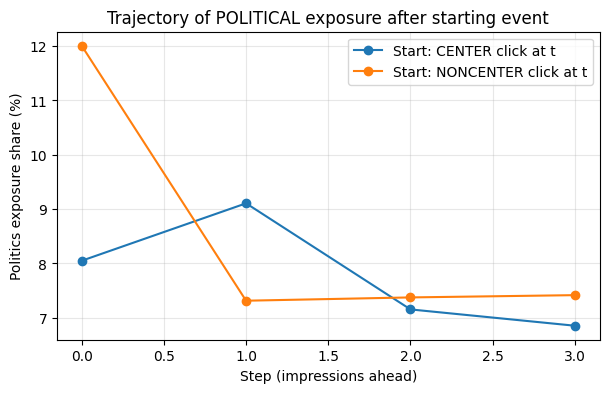

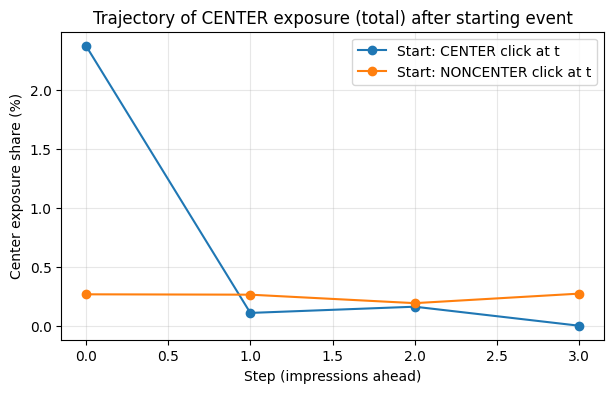

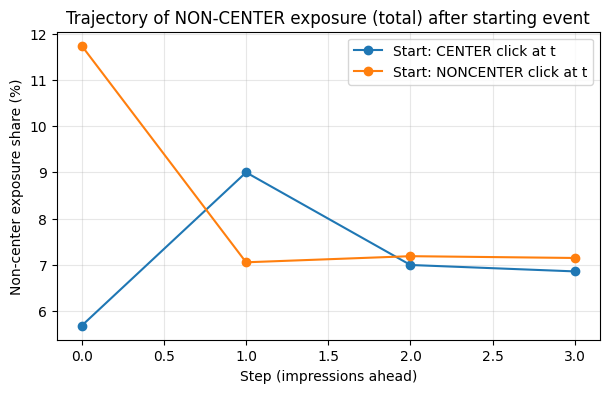

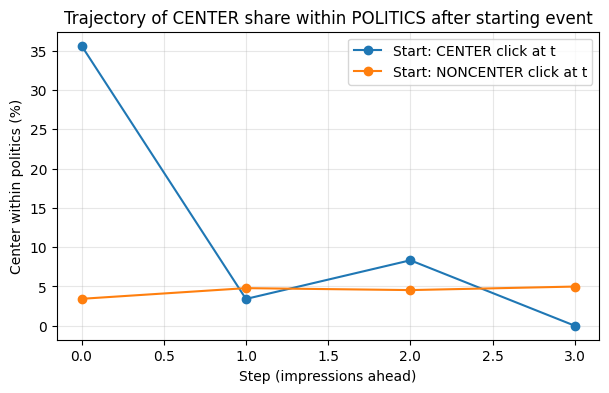

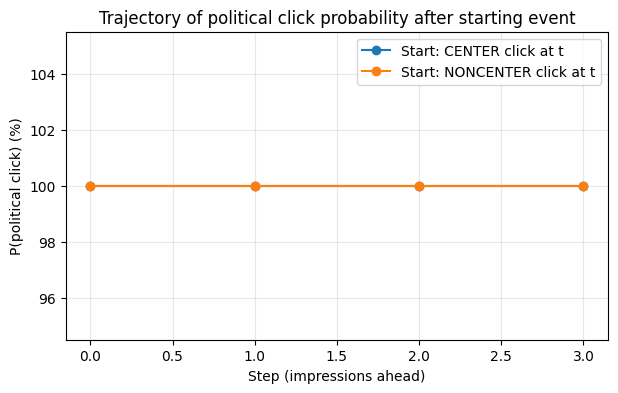

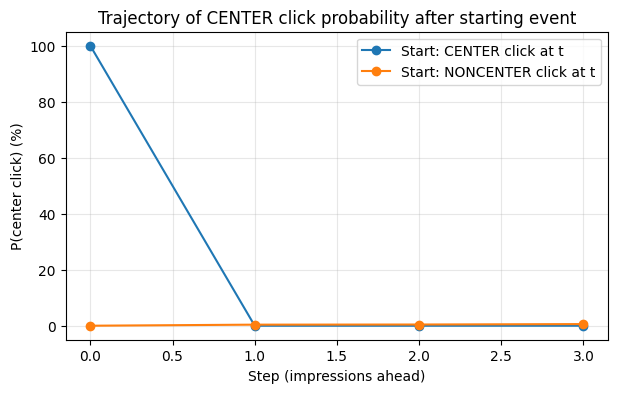

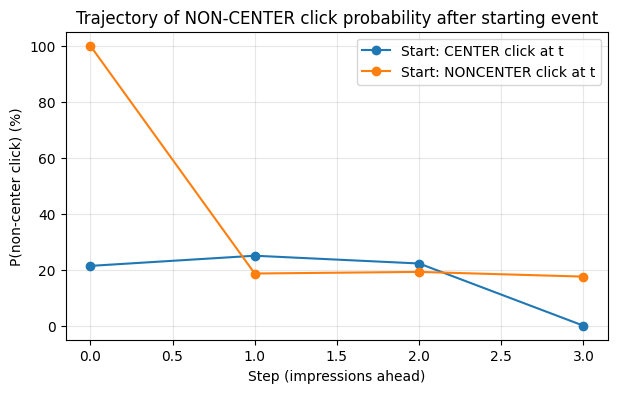

In [53]:
def plot_metric(traj, metric, title, y_label, as_percent=True):
    dfm = traj[traj["metric"] == metric].copy()
    if dfm.empty:
        print("No data for metric:", metric)
        return

    # Convert to % if requested (your plots are in percent)
    y = dfm["mean"] * (100.0 if as_percent else 1.0)
    dfm = dfm.assign(mean_plot=y)

    plt.figure(figsize=(7,4))
    for start_name, chunk in dfm.groupby("start"):
        plt.plot(chunk["step"], chunk["mean_plot"], marker="o", label=start_name)

    plt.title(title)
    plt.xlabel("Step (impressions ahead)")
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Exposure plots
plot_metric(traj, "exposure_politics",
            "Trajectory of POLITICAL exposure after starting event",
            "Politics exposure share (%)", as_percent=True)

plot_metric(traj, "exposure_center_total",
            "Trajectory of CENTER exposure (total) after starting event",
            "Center exposure share (%)", as_percent=True)

plot_metric(traj, "exposure_noncenter_total",
            "Trajectory of NON-CENTER exposure (total) after starting event",
            "Non-center exposure share (%)", as_percent=True)

plot_metric(traj, "center_within_politics",
            "Trajectory of CENTER share within POLITICS after starting event",
            "Center within politics (%)", as_percent=True)

# Click-probability plots
plot_metric(traj, "click_any_politics",
            "Trajectory of political click probability after starting event",
            "P(political click) (%)", as_percent=True)

plot_metric(traj, "click_center",
            "Trajectory of CENTER click probability after starting event",
            "P(center click) (%)", as_percent=True)

plot_metric(traj, "click_noncenter",
            "Trajectory of NON-CENTER click probability after starting event",
            "P(non-center click) (%)", as_percent=True)
